<a href="https://colab.research.google.com/github/giancarloliver/MTS-PolKA/blob/main/artigo/test1/result/run/functional_test_packets_profile_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Switches  packets_out
0      SW1        74134
1      SW2        25043
2      SW3        12077
3      SW5        24590
4      SW6        12416
5      SW7        74134


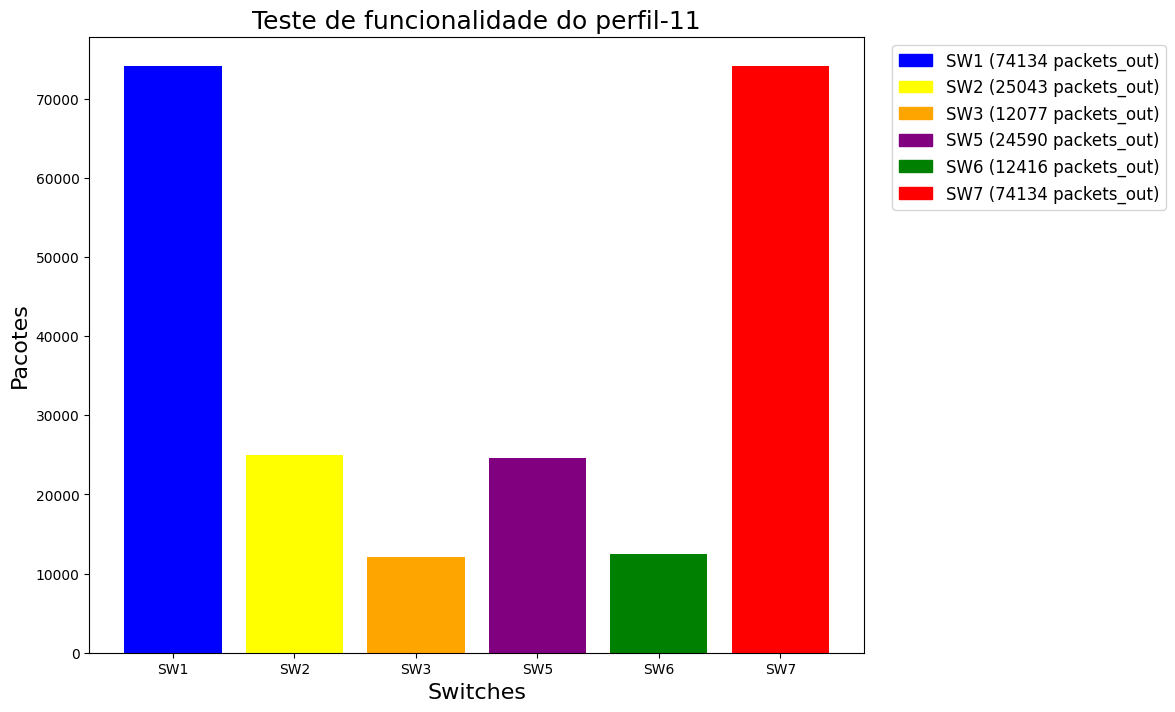

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import DataFrame, read_csv
from google.colab import files

# File path of the data file
arq ='drive/MyDrive/Colab Notebooks/Teste_Traffic_M-Polka/IdPerfil-11/s-11-tmp.bwm'

# Column names for the data
colunas = ['unix_timestamp', 'interface', 'bytes_out_s', 'bytes_in_s', 'bytes_total_s', 'bytes_in', 'bytes_out', 'packets_out_s', 'packets_in_s', 'packets_total_s', 'packets_in', 'packets_out', 'errors_out_s', 'errors_in_s', 'errors_in', 'errors_out']

# Read the data from the CSV file
data = pd.read_csv(arq, delimiter=',', usecols=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
data.columns = colunas

# Filter the data for each interface of the switches
# Filter the data for each switch
df_sw1 = data[data['interface'].str.contains('s1-eth')]
df_sw2 = data[data['interface'].str.contains('s2-eth')]
df_sw3 = data[data['interface'].str.contains('s3-eth')]
df_sw5 = data[data['interface'].str.contains('s5-eth')]
df_sw6 = data[data['interface'].str.contains('s6-eth')]
df_sw7 = data[data['interface'].str.contains('s7-eth')]

# Calculate the sum of packets in and out for each interface
df = pd.DataFrame([
                  ['SW1', sum(df_sw1['packets_out'])],
                  #['SW2', sum(df_s1_2['packets_in']), sum(df_s1_2['packets_out'])],
                  ['SW2', sum(df_sw2['packets_out'])],
                  ['SW3', sum(df_sw3['packets_out'])],
                  ['SW5', sum(df_sw5['packets_out'])],
                  ['SW6', sum(df_sw6['packets_out'])],
                  ['SW7', sum(df_sw7['packets_out']),]
                  ],
                  columns=['Switches', 'packets_out'])



print(df)

# Create a dictionary to map switches to colors
switch_colors = {'SW1': 'blue', 'SW2': 'yellow','SW3': 'orange', 'SW5': 'purple','SW6': 'green', 'SW7': 'red'}

# Create the bar chart with increased figure size
fig, ax = plt.subplots(figsize=(10, 8))

# Iterate over each row in the DataFrame and plot a bar for each switch
for idx, row in df.iterrows():
    switch = row['Switches']
    packets_out = row['packets_out']
    color = switch_colors.get(switch, 'gray')  # Use gray color if switch not found in dictionary
    ax.bar(switch, packets_out, color=color)

# Set the labels and title
ax.set_xlabel('Switches', fontsize=16)
ax.set_ylabel('Pacotes', fontsize=16)
ax.set_title('Teste de funcionalidade do perfil-11', fontsize=18)

# Create custom legend handles and labels
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in switch_colors.values()]
legend_labels = legend_labels = [f"{switch} ({packets_out} packets_out)" for switch, packets_out in zip(df['Switches'], df['packets_out'])]


# Move the legend to the upper right corner
ax.legend(legend_handles, legend_labels, fontsize=12, loc='upper right', bbox_to_anchor=(1.4, 1.))

# Display the plot
plt.show()
